# Analyse Exploratoire - Notebook 02

**Objectif**
Identifier les patterns comportementaux et démographiques associés au churn bancaire à travers des analyses poussées.

## 1. Import et vérification

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re 
import warnings

warnings.filterwarnings('ignore')
df = pd.read_csv('../data/preprocessed/01_churn_records.csv')
df = df.convert_dtypes()

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   row_number          10000 non-null  Int64  
 1   customer_id         10000 non-null  Int64  
 2   surname             10000 non-null  string 
 3   credit_score        10000 non-null  Int64  
 4   geography           10000 non-null  string 
 5   gender              10000 non-null  string 
 6   age                 10000 non-null  Int64  
 7   tenure              10000 non-null  Int64  
 8   balance             10000 non-null  Float64
 9   num_of_products     10000 non-null  Int64  
 10  has_cr_card         10000 non-null  Int64  
 11  is_active_member    10000 non-null  Int64  
 12  estimated_salary    10000 non-null  Float64
 13  exited              10000 non-null  Int64  
 14  complain            10000 non-null  Int64  
 15  satisfaction_score  10000 non-null  Int64  
 16  card_

**Dimensions** : 9,678 lignes × 18 colonnes

**Variables disponibles** :
- **Identifiants** (3) : `row_number`, `customer_id`, `surname`
- **Démographie** (3) : `geography`, `gender`, `age`
- **Financières** (4) : `credit_score`, `balance`, `estimated_salary`, `point_earned`
- **Comportementales** (5) : `tenure`, `num_of_products`, `has_cr_card`, `is_active_member`, `complain`
- **Produits** (2) : `card_type`, `satisfaction_score`
- **Cible** (1) : `exited`

**Qualité** : 0 valeur manquante, types corrects

## 2. Analyse du churn par variables

**Contexte** : Sur 10,000 clients, 2,080 ont quitté la banque

### 2.1 Variables catégorielles


Taux de churn global: 20.4%



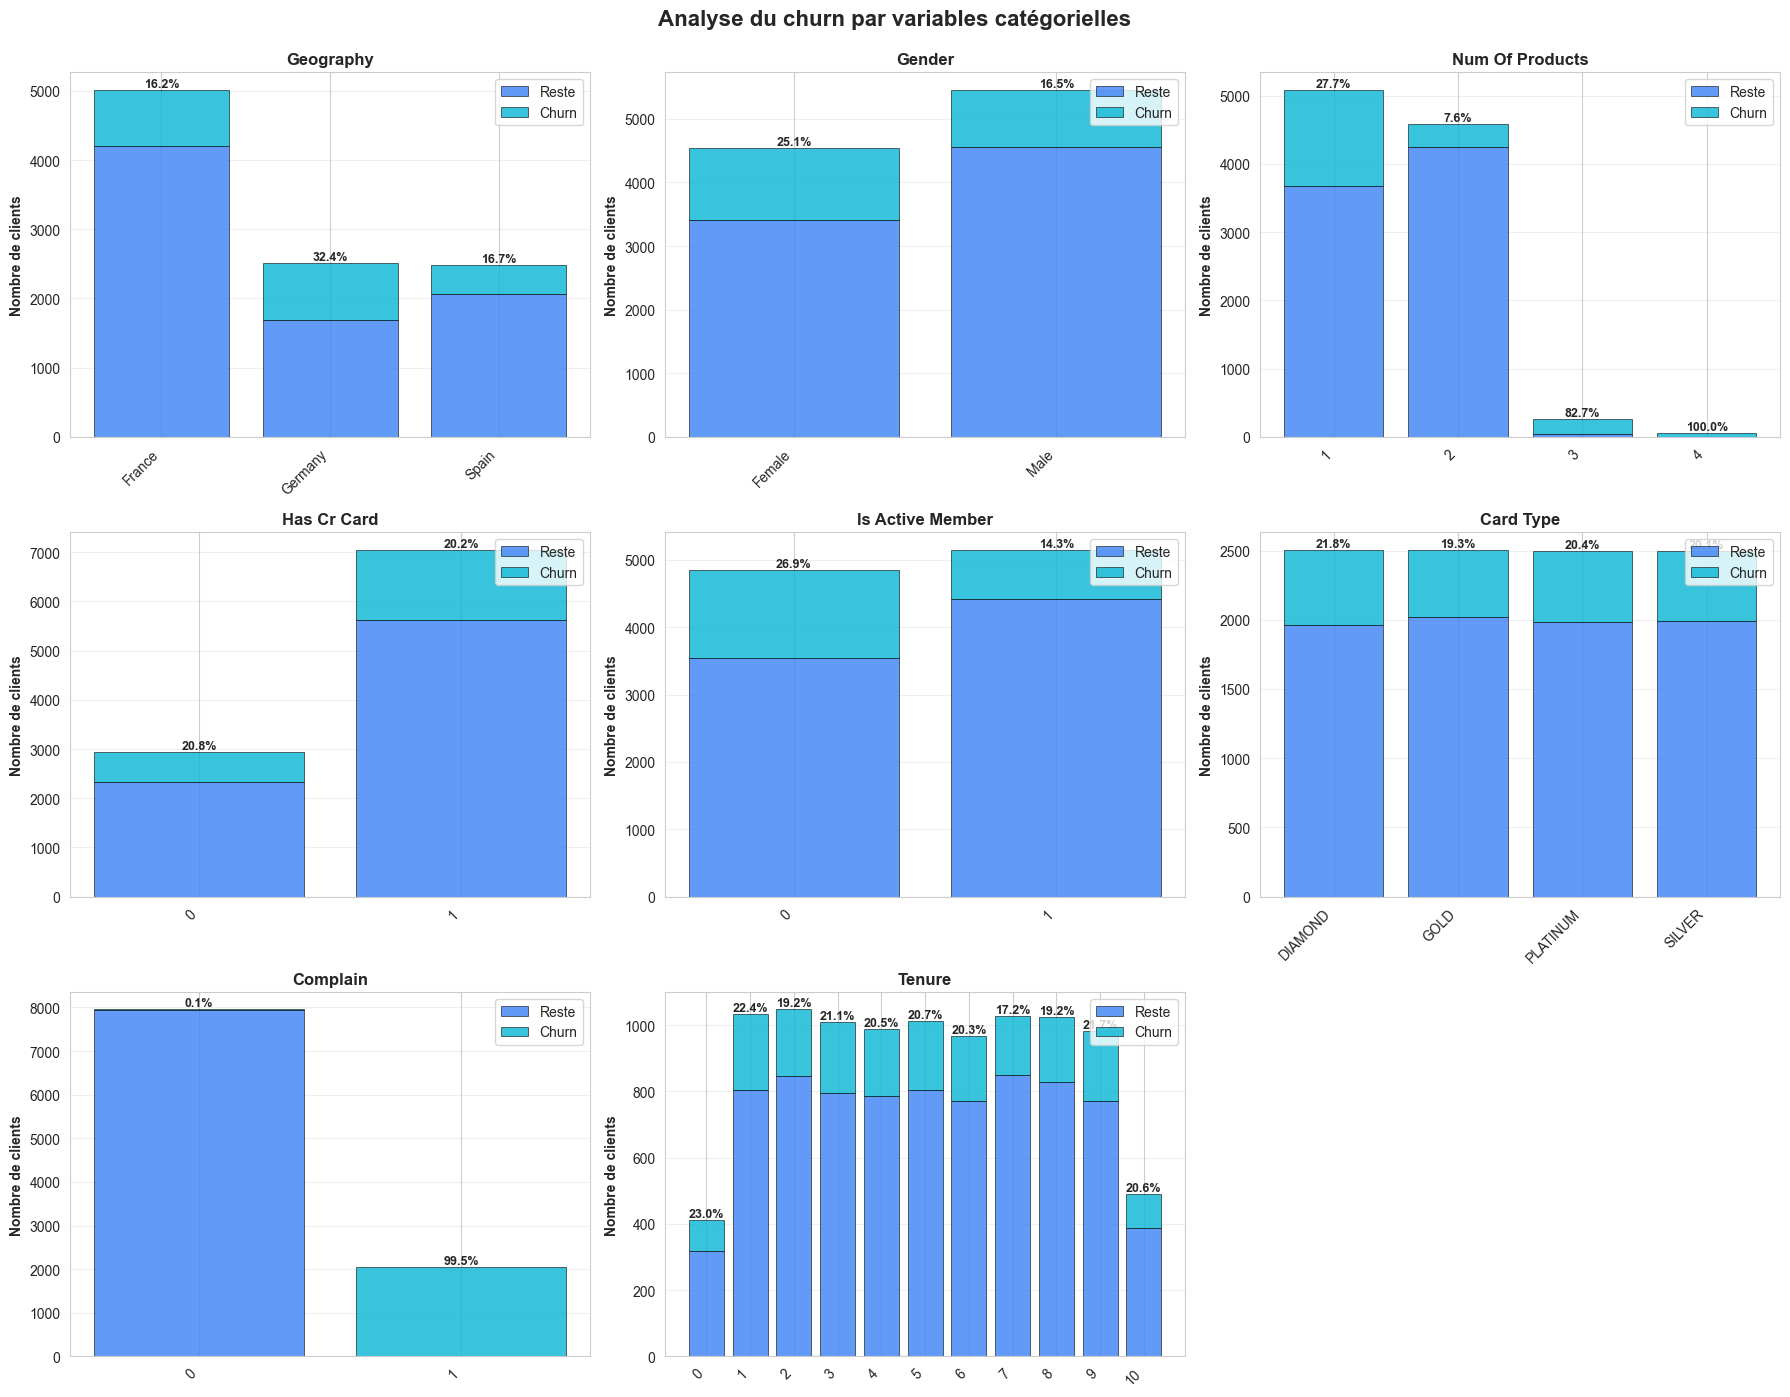

In [32]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (20, 16)
plt.rcParams['font.size'] = 10
stayed_color = '#3b82f6'
churned_color = '#06b6d4'

categorical_vars = ['geography', 'gender', 'num_of_products', 'has_cr_card', 
                    'is_active_member', 'card_type', 'complain', 'tenure']

# Calculer le taux de churn par variable
print(f"\nTaux de churn global: {df['exited'].mean()*100:.1f}%\n")

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for idx, var in enumerate(categorical_vars):
    ax = axes[idx]
    
    # Calculer le taux de churn par catégorie
    churn_by_cat = df.groupby(var).agg({
        'exited': ['sum', 'count', 'mean']
    }).round(3)
    
    churn_by_cat.columns = ['churned', 'total', 'churn_rate']
    churn_by_cat['stayed'] = churn_by_cat['total'] - churn_by_cat['churned']
    churn_by_cat = churn_by_cat.reset_index()
    
    x_pos = range(len(churn_by_cat))
    
    # Barres empilées
    p1 = ax.bar(x_pos, churn_by_cat['stayed'], label='Reste', 
                color=stayed_color, alpha=0.8, edgecolor='black', linewidth=0.5)
    p2 = ax.bar(x_pos, churn_by_cat['churned'], bottom=churn_by_cat['stayed'],
                label='Churn', color=churned_color, alpha=0.8, edgecolor='black', linewidth=0.5)
    
    for i, row in churn_by_cat.iterrows():
        ax.text(i, row['total'], f"{row['churn_rate']*100:.1f}%",
                ha='center', va='bottom', fontweight='bold', fontsize=9)
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(churn_by_cat[var], rotation=45, ha='right')
    ax.set_ylabel('Nombre de clients', fontweight='bold')
    ax.set_title(f'{var.replace("_", " ").title()}', fontweight='bold', fontsize=12)
    ax.legend(loc='upper right')
    ax.grid(axis='y', alpha=0.3)

# Supprimer les axes non utilisés
for idx in range(len(categorical_vars) , len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Analyse du churn par variables catégorielles', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

**Observations**
  * geography : Allemagne = 2× plus de churn
    * France : ~17%
    * Germany : ~33%
    * Spain : ~17%
  * gender : Femmes churnent 1.5× plus
    * Male : ~16%
    * Female : ~26%
  * num_of_products : Produits 3 et 4 catastrophiques
    * produit 1 : ~28%
    * produit 2 : ~8%
    * produit 3 : ~83%
    * produit 4 : ~100%
  * has_cr_card : Peu discriminant
    * Sans carte : ~22%
    * Avec carte : ~21%
  * is_active_member : Membres inactifs churnent 2× plus (TOP variable)
    * Inactif : ~28%
    * Actif : ~15%
  * card_type : Peu discriminant (Probable données artificielles)
    * DIAMOND : ~22%
    * GOLD : ~20%
    * PLATINUM : ~22%
    * SILVER : ~21%
  * complain : DATA LEAKAGE !
    * Sans plainte : ~1%
    * Avec plainte : ~99%
  * tenure : Peu discriminant (Probable données artificielles)
    * 0 ans : ~23%
    * 1-9 ans : ~20-23% 
    * 10 ans : ~23%

**Actions feature engineering**
  * geography
    * Création de feature ciblé allemagne
  * gender
    * Création de features ciblés femmes
  * num_of_product
    * Création de features ciblés sur le produit 1. Les produits 3 et 4 sont des catégories à eux seul qui explique le churn (pas besoin de features).
  * is_active_member
    * Création de features ciblés
  * complain
    * Supprimer la variable
  * tenure
    * Supprimer la variable
  * card_type
    * supprimer la variable
   

**Actions métiers**
  * geography
    * Programme de rétention ciblé clients allemands
  * gender
    * Étude qualitative sur besoins spécifiques femmes
  * num_of_product
    * Réadapter les offres des produits 3 et 4. Mise en avant du produit 2.
  * is_active_member
    * Campagnes de réactivation des inactifs
    * Actions pour maintenir l'activité

### 2.2 Variables discrètes

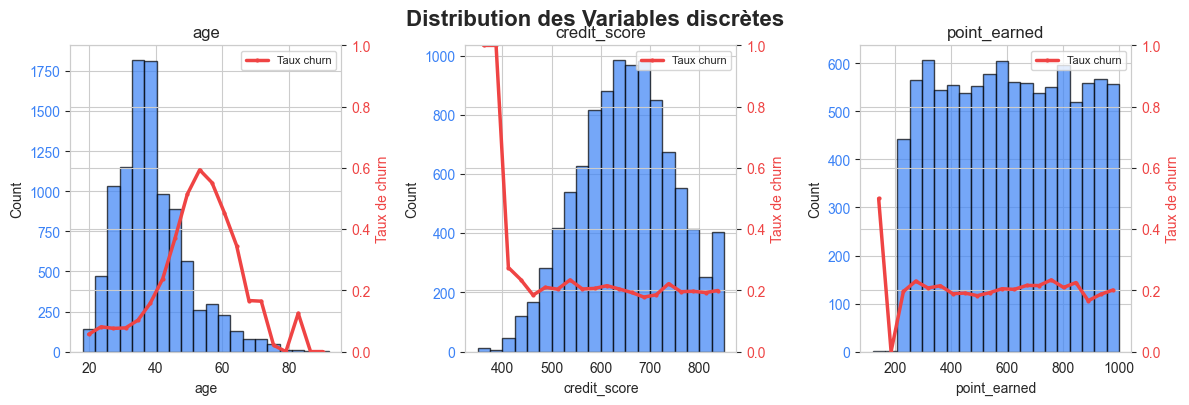

In [33]:
var_discrete = [
    'age', 'credit_score', 'point_earned'
]

# Créer la figure
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes = axes.flatten() 

# Pour chaque variable
for idx, var in enumerate(var_discrete):
    # Histogramme
    axes[idx].hist(df[var], bins=20, color='#3b82f6', edgecolor='black', alpha=0.7)
    axes[idx].set_ylabel("Count")
    axes[idx].tick_params(axis='y', labelcolor='#3b82f6')
    
    ax2 = axes[idx].twinx()
    
    bins_var = pd.cut(df[var], bins=20)
    churn_rate = df.groupby(bins_var)['exited'].mean()
    
    bin_centers = [interval.mid for interval in churn_rate.index]
    
    ax2.plot(bin_centers, churn_rate.values, 
             color='#ef4444', linewidth=2.5, marker='o', markersize=2, 
             label='Taux churn')
    ax2.set_ylabel("Taux de churn", color='#ef4444')
    ax2.tick_params(axis='y', labelcolor='#ef4444')
    ax2.set_ylim(0, 1)
    ax2.legend(loc='upper right', fontsize=8)
    
    axes[idx].set_title(var)
    axes[idx].set_xlabel(var)

    
plt.tight_layout()
plt.suptitle('Distribution des Variables discrètes\n', 
             fontsize=16, fontweight='bold', y=1.002)

plt.show()

**Observations**
  * age
    * 18-30 ans : ~7%
    * 30-45 ans : ~16%
    * 45-55 ans : ~50%
    * 55-65 ans : ~48%
    * 65+ ans : ~13%
  * credit_score
    * 0-450 : ~32% (Instable)
    * 450-1000 : ~20%
  * point_earned
    * 150-200 : ~50% (Instable)
    * 200-1000 : 20%
        
**Actions features**
  * age
    * Créer des bins (18-30, 30-45, 45-65, 65+)
  * credit_score
    * Créer un flag 'low_credit_score_risk' (credit_score <= 450)
  * point_earned
    * Créer un flag 'low_point_earned_risk' (point_earned <= 200)

**Actions métier**
  * age
    * Identifier les raisons du churn client entre 45 et 65ans.
    * Adapter produits pour cette tranche d'age

### 2.3 Variables continues

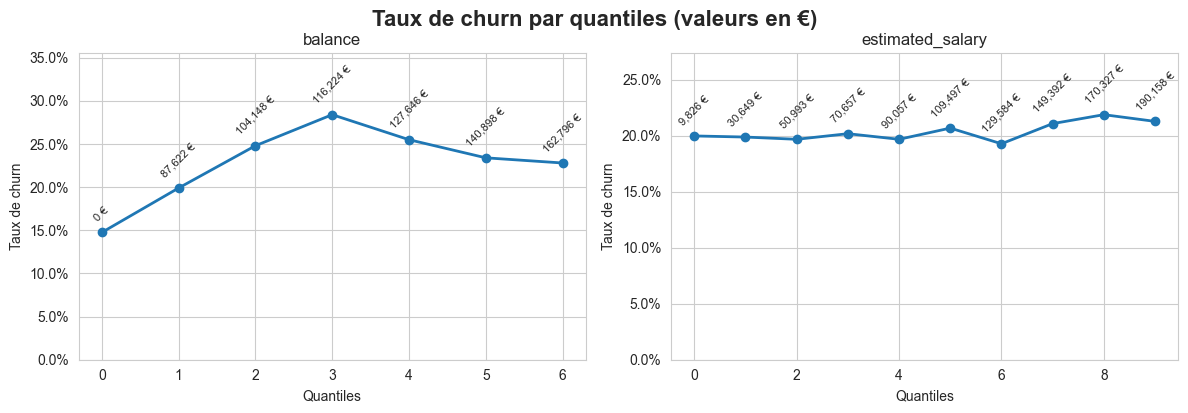

In [34]:
import matplotlib.ticker as mtick

var_continue = ['balance', 'estimated_salary']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes = axes.flatten()

for idx, var in enumerate(var_continue):
    
    bin_var = pd.qcut(df[var], q=10, duplicates='drop')
    
    churn_rate = df.groupby(bin_var)['exited'].mean()
    
    bin_values = df.groupby(bin_var)[var].median()
    
    x = range(len(churn_rate))
    
    axes[idx].plot(
        x,
        churn_rate.values,
        marker='o',
        linewidth=2
    )
    
    for i, (y, val) in enumerate(zip(churn_rate.values, bin_values.values)):
        axes[idx].annotate(
            f"{val:,.0f} €",
            (i, y),
            textcoords="offset points",
            xytext=(0, 8),
            ha='center',
            fontsize=8,
            rotation=45
        )
    
    axes[idx].set_title(var)
    axes[idx].set_xlabel("Quantiles")
    axes[idx].set_ylabel("Taux de churn")
    axes[idx].set_ylim(0, churn_rate.max() * 1.25)
    
    # Format % sur l’axe Y
    axes[idx].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.tight_layout()
plt.suptitle(
    "Taux de churn par quantiles (valeurs en €)\n",
    fontsize=16,
    fontweight='bold',
    y=1.02
)

plt.show()

**Observations**
  * balance
    * Courbe en cloche
    * <100K : Churn ~20%
    * 100K-140K : Pic de churn ~26%
    * >140K : Churn ~20%
  * estimated_salary
    * ~ 20% de churn (Uniforme)
    
**Actions features**
  * balance
    * Créer un flag 'medium_balance_risk' (100,000 <= balance <= 140,000)
  * estimated_salary (Variable probablement artificelle)
    * Créer une variable de ratio épargne/salaire pour étude
    
**Actions métiers**
   * balance
     * Classe moyenne supérieure (100K - 140K) : Identifier produits destinés aux personne trop riches pour accepter service standard mais pas assez riches pour bénéficier du service premium/private banking.

## 3. Correlations linéaire avec 'exited'

In [35]:
df = pd.get_dummies(df, columns=['geography', 'gender', 'card_type'])

df_corr = df.drop(columns=['row_number', 'customer_id', 'surname']).copy()

corr_matrix = df_corr.corr()['exited'].sort_values(ascending=False)

for label, value in corr_matrix.drop('exited').items():
    print(label + " " * (30-len(label)) + f"{value:.2f}" + "  " + "█" * int(abs(value) * 60))

complain                      1.00  ███████████████████████████████████████████████████████████
age                           0.29  █████████████████
geography_Germany             0.17  ██████████
balance                       0.12  ███████
gender_Female                 0.11  ██████
card_type_DIAMOND             0.02  █
estimated_salary              0.01  
card_type_PLATINUM            -0.00  
card_type_SILVER              -0.00  
point_earned                  -0.00  
satisfaction_score            -0.01  
has_cr_card                   -0.01  
tenure                        -0.01  
card_type_GOLD                -0.02  
credit_score                  -0.03  █
num_of_products               -0.05  ██
geography_Spain               -0.05  ███
geography_France              -0.10  ██████
gender_Male                   -0.11  ██████
is_active_member              -0.16  █████████


**Observations critiques**
  * complain : (r=1.00) => data leakage
  * satisfaction_score (r=-0.00) => devrait être corréler négativement (Confirmation donnée artificielle)
  * tenure (r=-0.00) => devrait réduire le churn (Confirmation donnée artificielle)
  * point_earned (r=-0.01) => devrait réduire le churn (Programme de fidélité inefficace)
  * card_type (r=~0.01) => aucun impact mesurable
    
**Actions features**
  * supprimer complain, satisfaction_score, tenure, point_earned, card_type

## 4. Validations et sauvegarde

In [36]:
print("="*80)
print("Vérification avant sauvegarde")
print("="*80)

print(f"Dimensions du dataframe : {df.shape}")
print(f"Valeurs manquantes : {df.isna().sum().sum()}")
print("\nTypes des colonnes :") 
print(df.dtypes)

df.to_csv('../data/preprocessed/02_churn_records.csv', index=False)
print(f"\ncsv sauvegardé à l'emplacement '../data/preprocessed/02_churn_records.csv'")

Vérification avant sauvegarde
Dimensions du dataframe : (10000, 24)
Valeurs manquantes : 0

Types des colonnes :
row_number                     Int64
customer_id                    Int64
surname               string[python]
credit_score                   Int64
age                            Int64
tenure                         Int64
balance                      Float64
num_of_products                Int64
has_cr_card                    Int64
is_active_member               Int64
estimated_salary             Float64
exited                         Int64
complain                       Int64
satisfaction_score             Int64
point_earned                   Int64
geography_France             boolean
geography_Germany            boolean
geography_Spain              boolean
gender_Female                boolean
gender_Male                  boolean
card_type_DIAMOND            boolean
card_type_GOLD               boolean
card_type_PLATINUM           boolean
card_type_SILVER             boolean

**Synthèse**

**Actions pour le feature engineering**
1. Suppression
 - complain
 - satisfaction_score
 - tenure
 - point_earned
 - card_type
 - estimated_salary
 - credit_score
 - row_number
 - customer_id
 - surname 
2. Flags
 - 'medium_balance_risk' (100,000 <= balance <= 140,000)
 - 'low_credit_score_risk' (credit_score <= 450)
 - 'low_point_earned_risk' (point_earned <= 200)
 - 'open_account_bf_major' (age - tenure < 18)
3. Bins
 - age (18-30, 30-45, 45-65, 65+)
4. Interactions
 - balance_capacity = ratio balance/estimated_salary
 - allemagne
 - femmes
 - is_active_member
 - produit 1
 - différentes interactions qui font sens (intéractions métier)

**Actions métiers**
1. Balance
 - Classe moyenne supérieure (100K - 140K) : Identifier produits destinés aux personne trop riches pour accepter service standard mais pas assez riches pour bénéficier du service premium/private banking.
 - Répondre aux besoins de la classe moyenne supérieure
2. Age
  - Identifier les raisons du churn client entre 45 et 65ans.
  - Adapter produits pour cette tranche d'age
3. Geography
  - Programme de rétention ciblé clients allemands
4. Gender
  - Étude qualitative sur besoins spécifiques femmes
5. Number of product
  - Réadapter les offres des produits 3 et 4. (Churn catastrophique)
  - Mise en avant du produit 2. (Fort taux de rétention)
6. Active member
  - Lancer une campagne de réactivation des membres inactifs
  - Lancer des actions pour maintenir l'activité des clients